# Korean Handwriting — EDA & Preprocessing
**Dataset:** Handwritten Hangul Korean Syllables (jkim289)  
**Source:** https://www.kaggle.com/datasets/jkim289/handwritten-korean-characters  

# **Import All Libraries**

In [1]:
import os
import numpy as np
import cv2
import seaborn as sns

import kagglehub
import shutil
import zipfile

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split


# **Step 1 - Download and Unzip the Dataset**

In [2]:
# Download to kagglehub cache first
cached_path = kagglehub.dataset_download("jkim289/handwritten-korean-characters")
print("Cached at:", cached_path)

# Copy to your project folder
TARGET_DIR = "data/raw"
os.makedirs(TARGET_DIR, exist_ok=True)
shutil.copytree(cached_path, TARGET_DIR, dirs_exist_ok=True)
print("Copied to:", TARGET_DIR)

DATASET_ROOT = TARGET_DIR

Download already complete (222026880 bytes).
Extracting files...
Cached at: C:\Users\ASUS TUF\.cache\kagglehub\datasets\jkim289\handwritten-korean-characters\versions\3
Copied to: data/raw


In [3]:
DOWNLOAD_DIR = "data"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Downloading dataset from Kaggle... (this may take a few minutes)")
!kaggle datasets download -d jkim289/handwritten-korean-characters -p {DOWNLOAD_DIR} --unzip

# Confirm what was downloaded
print("\n📁 Contents of data/:")
for item in sorted(Path(DOWNLOAD_DIR).rglob("*"))[:30]:
    print(" ", item)
print("  ...")


📁 Contents of data/:


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


  data\features_hog
  data\features_hog\X_test_hog.npy
  data\features_hog\X_train_hog.npy
  data\features_hog\X_val_hog.npy
  data\features_hog\y_test.npy
  data\features_hog\y_train.npy
  data\features_hog\y_val.npy
  data\raw
  data\raw\Hangul Database
  data\raw\Hangul Database\Hangul Database
  data\raw\Hangul Database\Hangul Database\a
  data\raw\Hangul Database\Hangul Database\a\아_0_0.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_1.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_2.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_3.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_4.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_5.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_6.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_7.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_8.jpg
  data\raw\Hangul Database\Hangul Database\a\아_0_9.jpg
  data\raw\Hangul Database\Hangul Database\a\아_1_0.jpg
  data\raw\Hangul Database\Hangul Database\a\아_1_1.

In [4]:
DATASET_ROOT = Path(cached_path) / "Hangul Database" / "Hangul Database"
print(f"✅ Correct dataset root: {DATASET_ROOT}")

# Verify
class_dirs  = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
CLASS_NAMES = [d.name for d in class_dirs]
print(f"Total classes : {len(CLASS_NAMES)}")
print(f"Classes       : {CLASS_NAMES}")

# Recount
counts = {}
SUPPORTED = {'.jpg', '.jpeg', '.png', '.bmp'}
for d in class_dirs:
    imgs = [f for f in d.iterdir() if f.suffix in SUPPORTED]
    counts[d.name] = len(imgs)

print(f"\nTotal images  : {sum(counts.values())}")
print(f"Min per class : {min(counts.values())}")
print(f"Max per class : {max(counts.values())}")

✅ Correct dataset root: C:\Users\ASUS TUF\.cache\kagglehub\datasets\jkim289\handwritten-korean-characters\versions\3\Hangul Database\Hangul Database
Total classes : 64
Classes       : ['a', 'bak', 'bo', 'bu', 'choe', 'da', 'dae', 'deul', 'do', 'dong', 'e', 'eo', 'eu', 'eui', 'eul', 'eun', 'ga', 'geos', 'geu', 'gi', 'gim', 'go', 'gong', 'gu', 'guk', 'gwa', 'gye', 'gyeong', 'ha', 'hae', 'han', 'hwa', 'i', 'il', 'in', 'iss', 'ja', 'jang', 'je', 'jeok', 'jeon', 'jeong', 'ji', 'jo', 'ju', 'na', 'neun', 'ra', 'reul', 'ri', 'ro', 'sa', 'sang', 'seo', 'seong', 'seu', 'si', 'so', 'su', 'wi', 'won', 'yeo', 'yeon', 'yong']

Total images  : 6400
Min per class : 100
Max per class : 100


# **Step 2 - EDA**

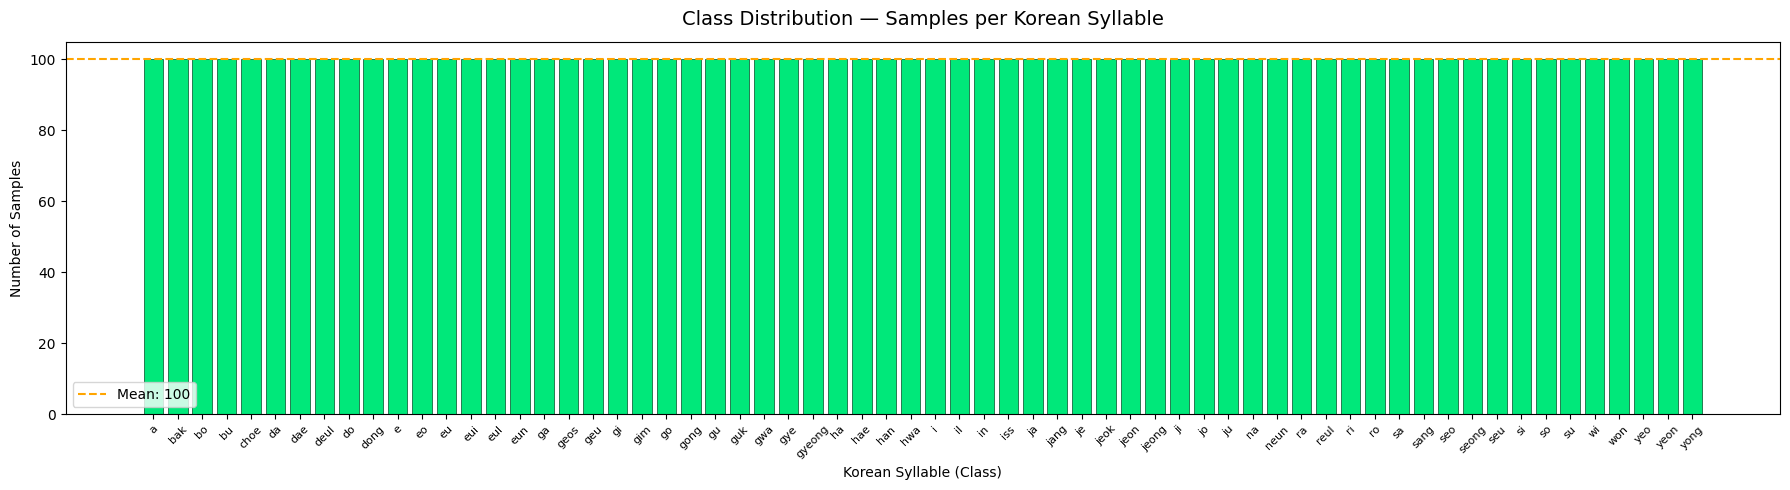

Imbalance ratio: 1.00x
✅ Dataset is well-balanced


In [5]:
os.makedirs("data/eda_output", exist_ok=True)

# ── 5a: Class distribution bar chart ─────────────────────────────────────── #
fig, ax = plt.subplots(figsize=(18, 5))

classes_sorted = sorted(counts.keys())
values_sorted  = [counts[c] for c in classes_sorted]

bars = ax.bar(classes_sorted, values_sorted, color='#00e87a', edgecolor='#004d26', linewidth=0.5)
ax.axhline(np.mean(values_sorted), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean: {np.mean(values_sorted):.0f}')
ax.set_title("Class Distribution — Samples per Korean Syllable", fontsize=14, pad=12)
ax.set_xlabel("Korean Syllable (Class)")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend()
plt.tight_layout()
plt.savefig("data/eda_output/01_class_distribution.png", dpi=150)
plt.show()

non_zero = [v for v in values_sorted if v > 0]
empty_classes = [c for c, v in counts.items() if v == 0]

if empty_classes:
    print(f"⚠️  Empty classes found: {empty_classes}")

imbalance = max(non_zero) / min(non_zero) if non_zero else 0
print(f"Imbalance ratio: {imbalance:.2f}x")
if imbalance < 2:
    print("✅ Dataset is well-balanced")
elif imbalance < 5:
    print("⚠️  Mild imbalance — consider light augmentation for minority classes")
else:
    print("❌ High imbalance — augmentation strongly recommended")

In [6]:
# ── 5b: Load a sample of images for visual EDA ───────────────────────────── #
# Load 5 images per class (just for EDA, not full load yet)

SUPPORTED = {'.jpg', '.jpeg', '.png', '.bmp'}
sample_images = {}

for class_name in CLASS_NAMES:
    class_dir = DATASET_ROOT / class_name
    files = sorted([f for f in class_dir.iterdir()
                    if f.suffix.lower() in SUPPORTED])[:5]
    imgs = []
    for f in files:
        try:
            img = Image.open(str(f)).convert('L')  # L = grayscale
            img = img.resize((64, 64))
            imgs.append(np.array(img))
        except Exception as e:
            print(f"Failed: {f.name} — {e}")
    sample_images[class_name] = imgs

total_loaded = sum(len(v) for v in sample_images.values())
print(f"✅ Loaded {total_loaded} sample images for EDA")

✅ Loaded 320 sample images for EDA


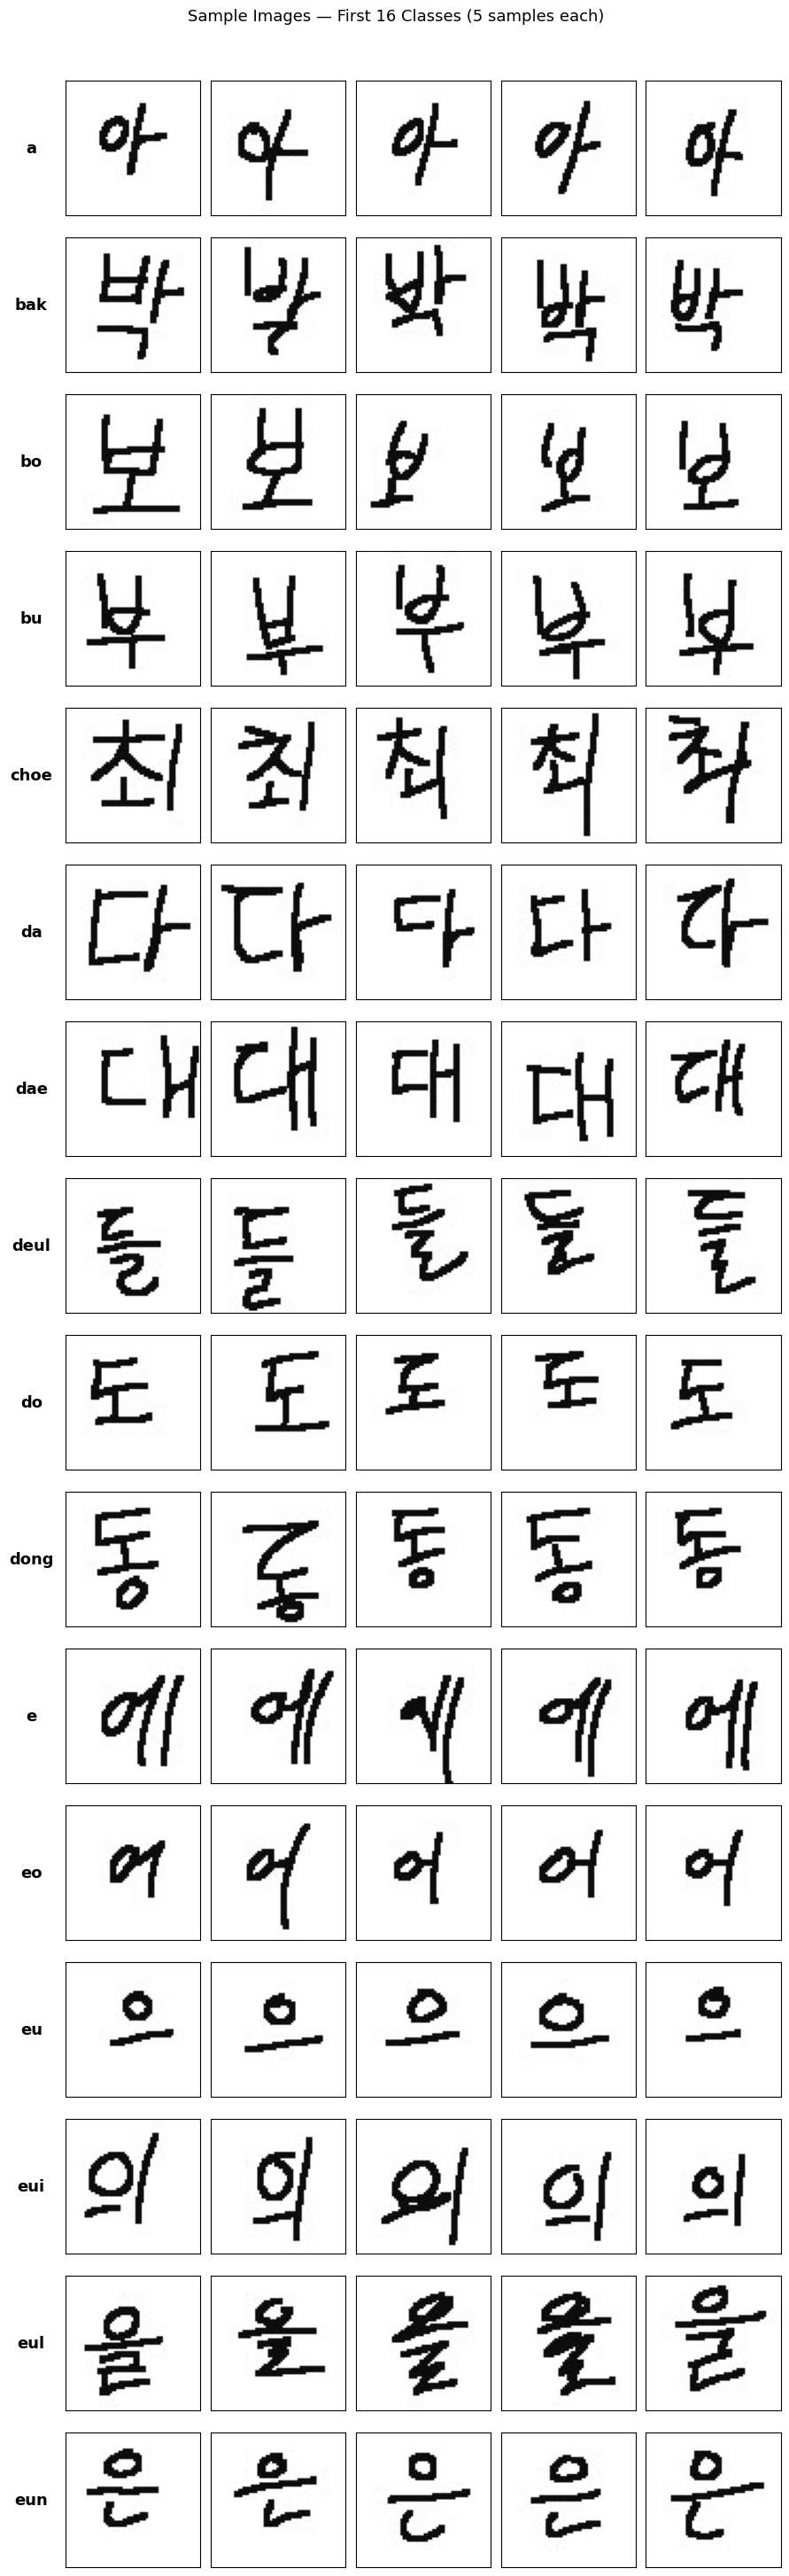

In [7]:
# ── 5c: Sample grid — show what the data actually looks like ─────────────── #
n_show_classes = min(len(CLASS_NAMES), 16)
n_show_samples = 5

fig, axes = plt.subplots(n_show_classes, n_show_samples,
    figsize=(n_show_samples * 1.8, n_show_classes * 1.8))

for row, class_name in enumerate(CLASS_NAMES[:n_show_classes]):
    imgs = sample_images[class_name]
    for col in range(n_show_samples):
        ax = axes[row][col]
        if col < len(imgs):
            ax.imshow(imgs[col], cmap='gray', vmin=0, vmax=255)
        else:
            ax.set_facecolor('#111111')
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(class_name, fontsize=13, rotation=0,
                          labelpad=28, va='center', fontweight='bold')

plt.suptitle(f"Sample Images — First {n_show_classes} Classes (5 samples each)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("data/eda_output/02_sample_grid.png", dpi=150, bbox_inches='tight')
plt.show()

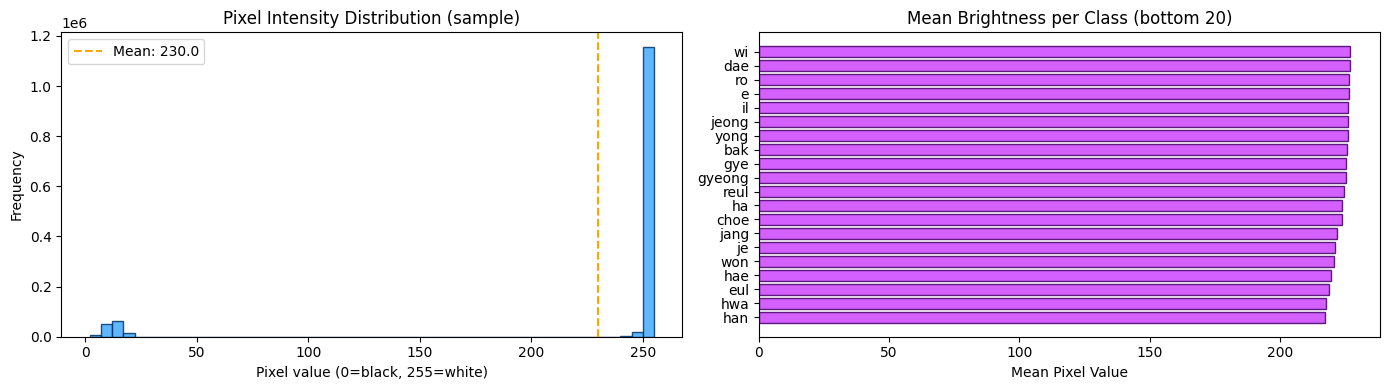

Global mean  : 229.95
Global std   : 73.06
Min pixel    : 2
Max pixel    : 255
✅ Images appear mostly light (standard: dark strokes on white background)


In [8]:
# ── 5d: Pixel intensity distribution ─────────────────────────────────────── #
all_sample_pixels = np.concatenate([
    np.array(v).ravel() for v in sample_images.values() if v
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(all_sample_pixels, bins=50, color='#44aaff', edgecolor='#003366', alpha=0.85)
axes[0].set_title("Pixel Intensity Distribution (sample)")
axes[0].set_xlabel("Pixel value (0=black, 255=white)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(all_sample_pixels.mean(), color='orange', linestyle='--',
                label=f"Mean: {all_sample_pixels.mean():.1f}")
axes[0].legend()

# Mean brightness per class
mean_brightness = {c: np.mean(v) for c, v in sample_images.items() if v}
sorted_mb = sorted(mean_brightness.items(), key=lambda x: x[1])
axes[1].barh([x[0] for x in sorted_mb[:20]],
             [x[1] for x in sorted_mb[:20]],
             color='#cc44ff', edgecolor='#440066', alpha=0.85)
axes[1].set_title("Mean Brightness per Class (bottom 20)")
axes[1].set_xlabel("Mean Pixel Value")

plt.tight_layout()
plt.savefig("data/eda_output/03_pixel_distribution.png", dpi=150)
plt.show()

print(f"Global mean  : {all_sample_pixels.mean():.2f}")
print(f"Global std   : {all_sample_pixels.std():.2f}")
print(f"Min pixel    : {all_sample_pixels.min()}")
print(f"Max pixel    : {all_sample_pixels.max()}")
if all_sample_pixels.mean() < 128:
    print("⚠️  Images appear mostly dark — will invert during preprocessing")
else:
    print("✅ Images appear mostly light (standard: dark strokes on white background)")

In [9]:
# ── 5e : Image size consistency check ─────────────────────────────────────────── #
sizes = set()
for class_name in CLASS_NAMES[:5]:
    class_dir = DATASET_ROOT / class_name
    for f in list(class_dir.iterdir())[:10]:
        if f.suffix.lower() in SUPPORTED:
            try:
                img = Image.open(str(f))
                sizes.add(img.size)  # (width, height)
            except:
                pass

print("Unique image sizes found:", sizes)
if len(sizes) == 1:
    print("✅ All images are the same size")
else:
    print("⚠️  Mixed sizes — preprocessing will normalize to 64×64")

# ── Blank / corrupt image check ───────────────────────────────────────────── #
blank_found = 0
for class_name in CLASS_NAMES:
    class_dir = DATASET_ROOT / class_name
    for f in class_dir.iterdir():
        if f.suffix.lower() not in SUPPORTED:
            continue
        try:
            img = np.array(Image.open(str(f)).convert('L'))
            if img.std() < 5:
                print(f"⚠️  Possibly blank: {f.name}  (std={img.std():.2f})")
                blank_found += 1
        except:
            print(f"❌ Cannot read: {f.name}")
            blank_found += 1

if blank_found == 0:
    print("✅ No blank or corrupt images found")
else:
    print(f"\nFound {blank_found} problematic images")

Unique image sizes found: {(64, 64)}
✅ All images are the same size
✅ No blank or corrupt images found


# **Step 3 - Full Data Load + Preprocessing**

In [10]:
IMG_SIZE = 64   # must match your model's input size

def load_and_preprocess(dataset_root, class_names, img_size):
    """
    Load ALL images, preprocess each:
      1. Grayscale
      2. Invert if background is dark
      3. Otsu binarization (removes noise)
      4. Auto-crop to bounding box of strokes + padding
      5. Resize to img_size × img_size
      6. Normalize to [0.0, 1.0]
    Returns X (N, H, W, 1), y (N,)
    """
    X, y = [], []
    skipped = 0

    for label_idx, class_name in enumerate(tqdm(class_names, desc="Loading")):
        class_dir = Path(dataset_root) / class_name
        files = [f for f in class_dir.iterdir() if f.suffix.lower() in SUPPORTED]

        for fpath in files:
            try:
                img = np.array(Image.open(str(fpath)).convert('L'))
            except:
                skipped += 1
                continue
            if img.std() < 5:
                skipped += 1
                continue
            
            # 1. Invert if mostly dark background
            if img.mean() < 128:
                img = cv2.bitwise_not(img)

            # 2. Otsu binarization
            _, img = cv2.threshold(img, 0, 255,
                                   cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            # 3. Auto-crop to stroke bounding box
            coords = cv2.findNonZero(img)
            if coords is not None:
                x, y_coord, w, h = cv2.boundingRect(coords)
                pad = 6
                x1 = max(0, x - pad)
                y1 = max(0, y_coord - pad)
                x2 = min(img.shape[1], x + w + pad)
                y2 = min(img.shape[0], y_coord + h + pad)
                img = img[y1:y2, x1:x2]

            # 4. Resize
            img = cv2.resize(img, (img_size, img_size),
                             interpolation=cv2.INTER_LANCZOS4)

            # 5. Normalize + add channel dim
            img_norm = img.astype(np.float32) / 255.0
            X.append(img_norm[..., np.newaxis])
            y.append(label_idx)

    print(f"\nSkipped {skipped} blank/corrupt images")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X, y = load_and_preprocess(DATASET_ROOT, CLASS_NAMES, IMG_SIZE)

print(f"\n✅ Loaded and preprocessed")
print(f"   X shape : {X.shape}   (N, H, W, C)")
print(f"   y shape : {y.shape}")
print(f"   X range : [{X.min():.3f}, {X.max():.3f}]")
print(f"   X dtype : {X.dtype}")

Loading: 100%|█████████████████████████████████████████████████████████████████████████| 64/64 [00:04<00:00, 14.16it/s]



Skipped 0 blank/corrupt images

✅ Loaded and preprocessed
   X shape : (6400, 64, 64, 1)   (N, H, W, C)
   y shape : (6400,)
   X range : [0.000, 1.000]
   X dtype : float32


# **Step 4 - Verify Preprocessed Images**

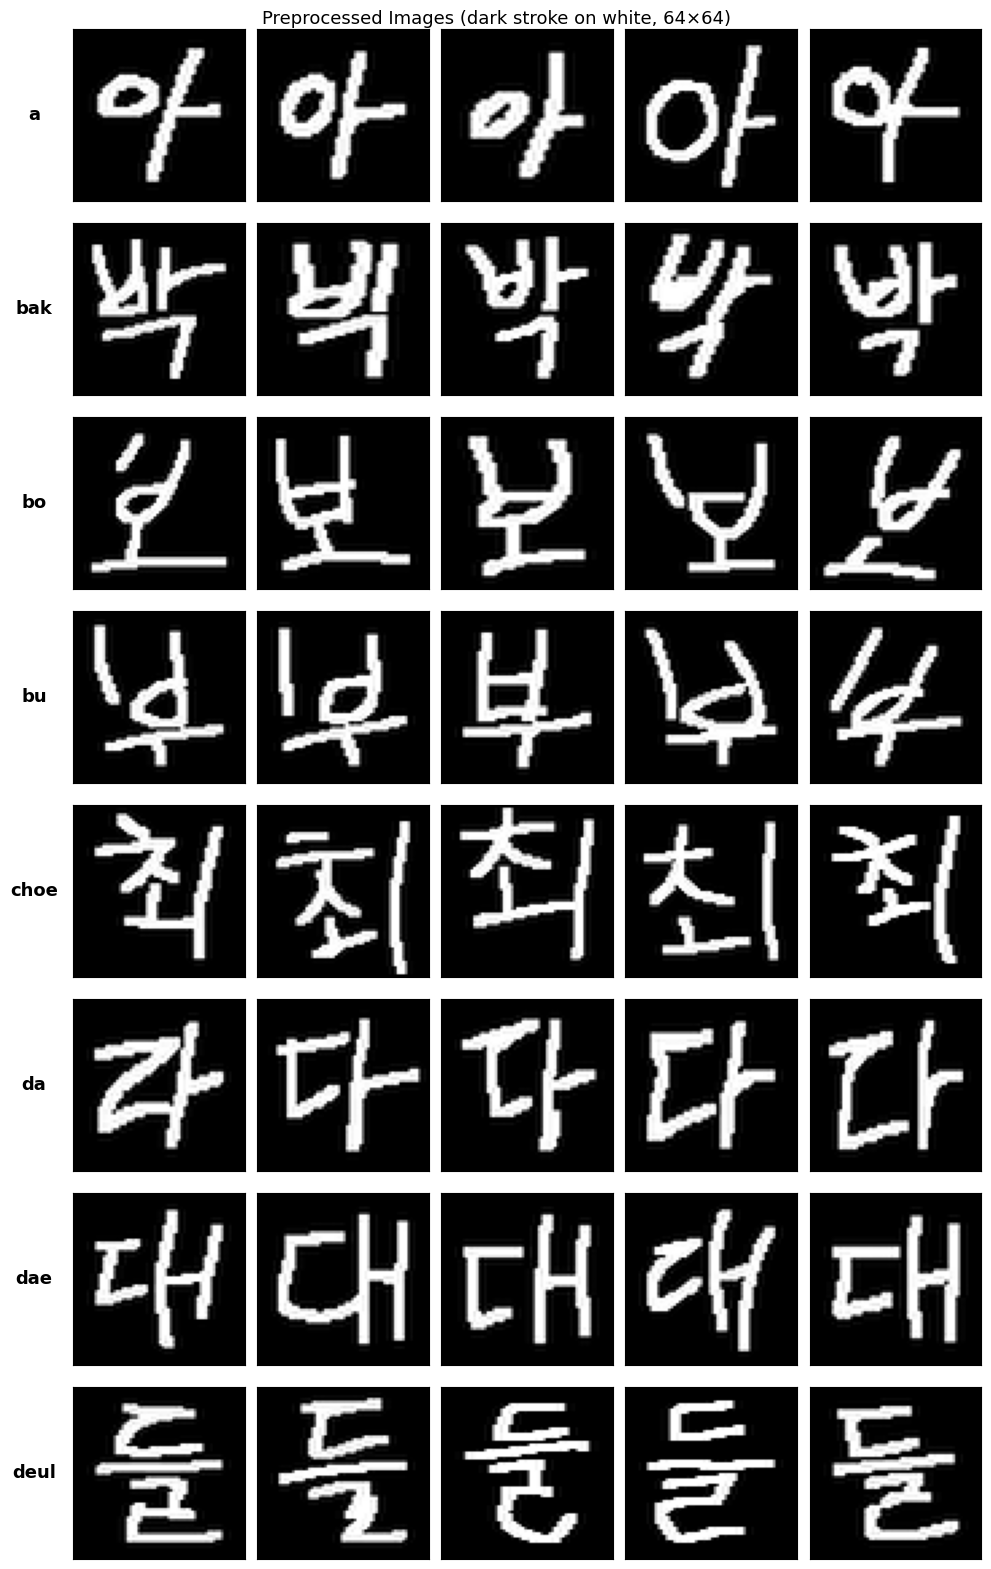

✅ If strokes are dark and clearly visible — preprocessing is correct
❌ If images are inverted (white stroke on black) — flip the invert logic in load_and_preprocess


In [11]:
# Show 5 preprocessed images per class (first 8 classes)
n_show = min(8, len(CLASS_NAMES))
n_cols = 5

fig, axes = plt.subplots(n_show, n_cols, figsize=(n_cols * 2, n_show * 2))

for row in range(n_show):
    class_mask = np.where(y == row)[0]
    samples    = np.random.choice(class_mask, min(n_cols, len(class_mask)), replace=False)
    for col in range(n_cols):
        ax = axes[row][col]
        if col < len(samples):
            ax.imshow(X[samples[col], :, :, 0], cmap='gray', vmin=0, vmax=1)
        else:
            ax.set_facecolor('#111')
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[row], fontsize=13, rotation=0,
                          labelpad=28, va='center', fontweight='bold')

plt.suptitle("Preprocessed Images (dark stroke on white, 64×64)", fontsize=13)
plt.tight_layout()
plt.savefig("data/eda_output/04_preprocessed_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ If strokes are dark and clearly visible — preprocessing is correct")
print("❌ If images are inverted (white stroke on black) — flip the invert logic in load_and_preprocess")

# **Step 5 - Train/Val/Test Split Dataset**

In [12]:
TEST_SPLIT = 0.15
VAL_SPLIT  = 0.15
SEED       = 42

# Split off test first
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=y
)

# Split val from remaining
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=y_trainval
)

total = len(X)
print("✅ Split complete")
print(f"   Train : {len(X_train):>6}  ({len(X_train)/total*100:.1f}%)")
print(f"   Val   : {len(X_val):>6}  ({len(X_val)/total*100:.1f}%)")
print(f"   Test  : {len(X_test):>6}  ({len(X_test)/total*100:.1f}%)")

# Verify class balance in each split
print(f"\nUnique classes in train : {len(np.unique(y_train))}")
print(f"Unique classes in val   : {len(np.unique(y_val))}")
print(f"Unique classes in test  : {len(np.unique(y_test))}")

✅ Split complete
   Train :   4479  (70.0%)
   Val   :    961  (15.0%)
   Test  :    960  (15.0%)

Unique classes in train : 64
Unique classes in val   : 64
Unique classes in test  : 64


# **Step 6 - Save the Preprocessed Images into new Folder**

In [13]:
OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

files_to_save = {
    "X_train.npy":     X_train,
    "y_train.npy":     y_train,
    "X_val.npy":       X_val,
    "y_val.npy":       y_val,
    "X_test.npy":      X_test,
    "y_test.npy":      y_test,
    "class_names.npy": np.array(CLASS_NAMES),
}

for fname, arr in files_to_save.items():
    path = os.path.join(OUTPUT_DIR, fname)
    np.save(path, arr)
    size_mb = os.path.getsize(path) / 1024 / 1024
    print(f"   Saved {fname:<22}  {arr.shape}  {size_mb:.1f} MB")

print(f"\n✅ All files saved to '{OUTPUT_DIR}/'")
print(f"\nSummary for your friend:")
print(f"  Image size    : {IMG_SIZE}×{IMG_SIZE}×1  (grayscale)")
print(f"  Value range   : [0.0, 1.0]  (normalized)")
print(f"  Total classes : {len(CLASS_NAMES)}")
print(f"  Class list    : {CLASS_NAMES}")
print(f"\nHow to load in training notebook:")
print("""
  X_train     = np.load('data/processed/X_train.npy')
  y_train     = np.load('data/processed/y_train.npy')
  X_val       = np.load('data/processed/X_val.npy')
  y_val       = np.load('data/processed/y_val.npy')
  X_test      = np.load('data/processed/X_test.npy')
  y_test      = np.load('data/processed/y_test.npy')
  class_names = np.load('data/processed/class_names.npy', allow_pickle=True)
""")

   Saved X_train.npy             (4479, 64, 64, 1)  70.0 MB
   Saved y_train.npy             (4479,)  0.0 MB
   Saved X_val.npy               (961, 64, 64, 1)  15.0 MB
   Saved y_val.npy               (961,)  0.0 MB
   Saved X_test.npy              (960, 64, 64, 1)  15.0 MB
   Saved y_test.npy              (960,)  0.0 MB
   Saved class_names.npy         (64,)  0.0 MB

✅ All files saved to 'data/processed/'

Summary for your friend:
  Image size    : 64×64×1  (grayscale)
  Value range   : [0.0, 1.0]  (normalized)
  Total classes : 64
  Class list    : ['a', 'bak', 'bo', 'bu', 'choe', 'da', 'dae', 'deul', 'do', 'dong', 'e', 'eo', 'eu', 'eui', 'eul', 'eun', 'ga', 'geos', 'geu', 'gi', 'gim', 'go', 'gong', 'gu', 'guk', 'gwa', 'gye', 'gyeong', 'ha', 'hae', 'han', 'hwa', 'i', 'il', 'in', 'iss', 'ja', 'jang', 'je', 'jeok', 'jeon', 'jeong', 'ji', 'jo', 'ju', 'na', 'neun', 'ra', 'reul', 'ri', 'ro', 'sa', 'sang', 'seo', 'seong', 'seu', 'si', 'so', 'su', 'wi', 'won', 'yeo', 'yeon', 'yong']

How to

# **Step 7 - EDA Summary Report**

In [14]:
print("=" * 55)
print("        EDA & PREPROCESSING SUMMARY REPORT")
print("=" * 55)
print(f"  Dataset       : jkim289/handwritten-korean-characters")
print(f"  Total classes : {len(CLASS_NAMES)}")
print(f"  Total images  : {len(X)}")
print(f"  Image size    : {IMG_SIZE}×{IMG_SIZE}×1")
print(f"  Value range   : [0.0, 1.0]")
print()
print(f"  Splits:")
print(f"    Train  : {len(X_train)}")
print(f"    Val    : {len(X_val)}")
print(f"    Test   : {len(X_test)}")
print()
print(f"  Class balance : {'Good ✅' if max(values_sorted)/min(values_sorted) < 2 else 'Imbalanced ⚠️'}")
print(f"  EDA plots saved to : data/eda_output/")
print(f"  Processed data saved to : data/processed/")
print("=" * 55)
print("  ✅ Done. Hand the data/processed/ folder to your friend.")
print("=" * 55)

        EDA & PREPROCESSING SUMMARY REPORT
  Dataset       : jkim289/handwritten-korean-characters
  Total classes : 64
  Total images  : 6400
  Image size    : 64×64×1
  Value range   : [0.0, 1.0]

  Splits:
    Train  : 4479
    Val    : 961
    Test   : 960

  Class balance : Good ✅
  EDA plots saved to : data/eda_output/
  Processed data saved to : data/processed/
  ✅ Done. Hand the data/processed/ folder to your friend.
